In [1]:
import pandas as pd

fraud = pd.read_csv("../data/creditcard.csv")

In [2]:
fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
fraud.shape

(284807, 31)

In [4]:
fraud.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
fraud['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
fraud['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

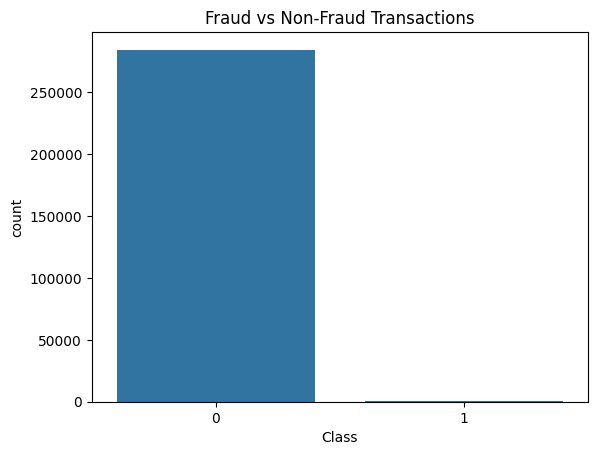

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=fraud)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [9]:
X = fraud.drop('Class', axis=1)

In [10]:
y = fraud['Class']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

c:\Users\anusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
y_pred = model.predict(X_test)


In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



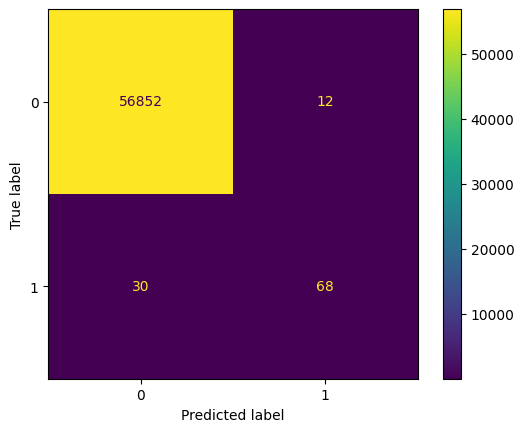

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,30
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
rf_pred = rf.predict(X_test)

In [21]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
17,V17,0.229837
14,V14,0.200147
12,V12,0.105169
10,V10,0.075442
16,V16,0.073755
9,V9,0.040111
4,V4,0.030108
3,V3,0.028228
7,V7,0.018250
18,V18,0.018038


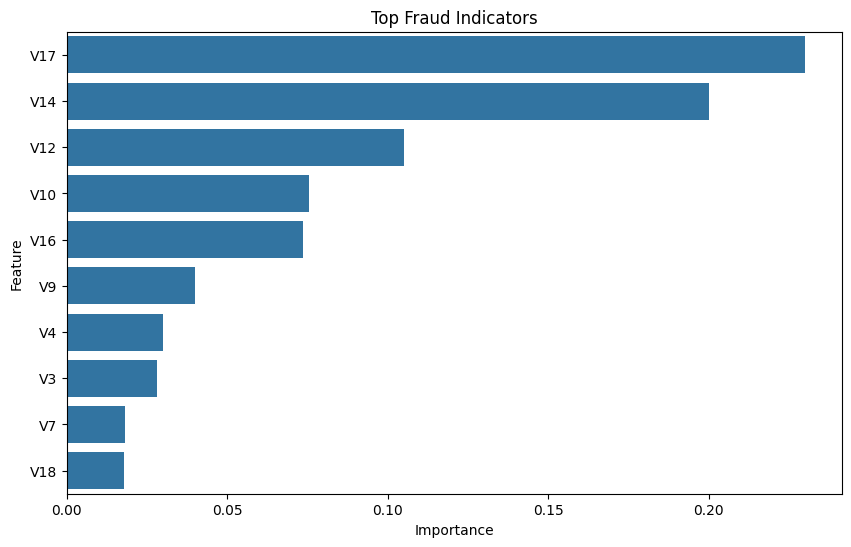

In [23]:
top10 = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top Fraud Indicators"
)

plt.show()

In [24]:
fraud['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [25]:
fraud['Class'].value_counts(normalize=True)*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [26]:
from sklearn.model_selection import train_test_split

X = fraud.drop('Class', axis=1)
y = fraud['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

c:\Users\anusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = lr.predict(X_test)

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [31]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr_balanced.fit(
    X_train,
    y_train
)

y_pred_balanced = lr_balanced.predict(
    X_test
)

c:\Users\anusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.91      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962



In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [34]:
print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.91      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962



In [35]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [37]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [39]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    rf_pred
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9030084670334088


In [41]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
17,V17,0.229837
14,V14,0.200147
12,V12,0.105169
10,V10,0.075442
16,V16,0.073755
9,V9,0.040111
4,V4,0.030108
3,V3,0.028228
7,V7,0.018250
18,V18,0.018038


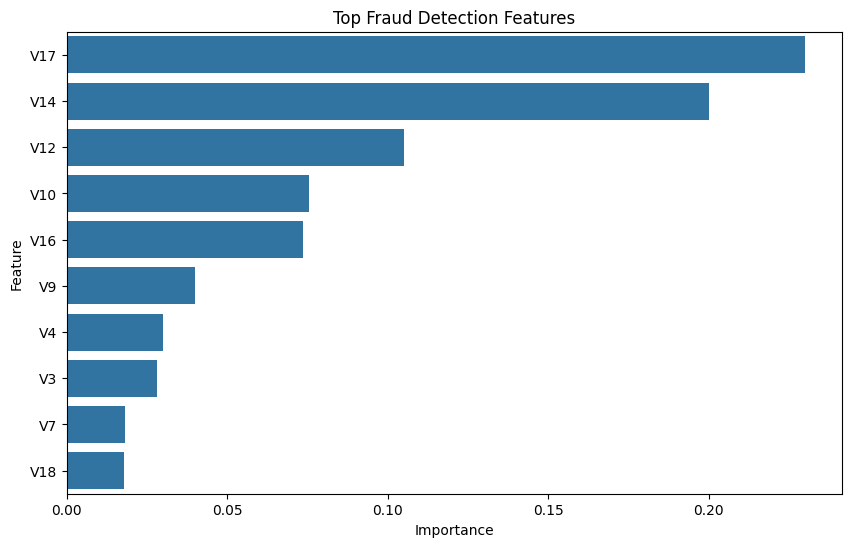

In [43]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top Fraud Detection Features"
)

plt.show()

In [ ]:
import sys

!{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 4.0 MB/s eta 0:00:10
    --------------------------------------- 0.8/38.1 MB 2.3 MB/s eta 0:00:17
   - -------------------------------------- 1.3/38.1 MB 2.4 MB/s eta 0:00:16
   -- ------------------------------------- 2.1/38.1 MB 2.4 MB/s eta 0:00:16
   -- ------------------------------------- 2.6/38.1 MB 2.5 MB/s eta 0:00:15
   --- ------------------------------------ 3.1/38.1 MB 2.6 MB/s eta 0:00:14
   ---- ----------------------------------- 4.2/38.1 MB 2.8 MB/s eta 0:00:13
   ---- ----------------------------------- 4.7/38.1 MB 2.9 MB/s eta 0:00:12
   ----- ---------------------------------- 5.5/38.1 MB 3.0 MB/s eta 0:00:11
   ------ --------------------------------- 6.3/38.1 MB 3.1 MB/s eta 0:00:11
   ------- -------------------------------- 6.8/38.1 MB 3.0 MB/s eta 0:00:11
   ------- -------------------------------- 7.6/38.1 MB 3.0 MB/s eta 0:00:11
   ---


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

In [47]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [48]:
import numpy as np

print(np.array(shap_values).shape)

(56962, 30, 2)


In [49]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer(X_test)

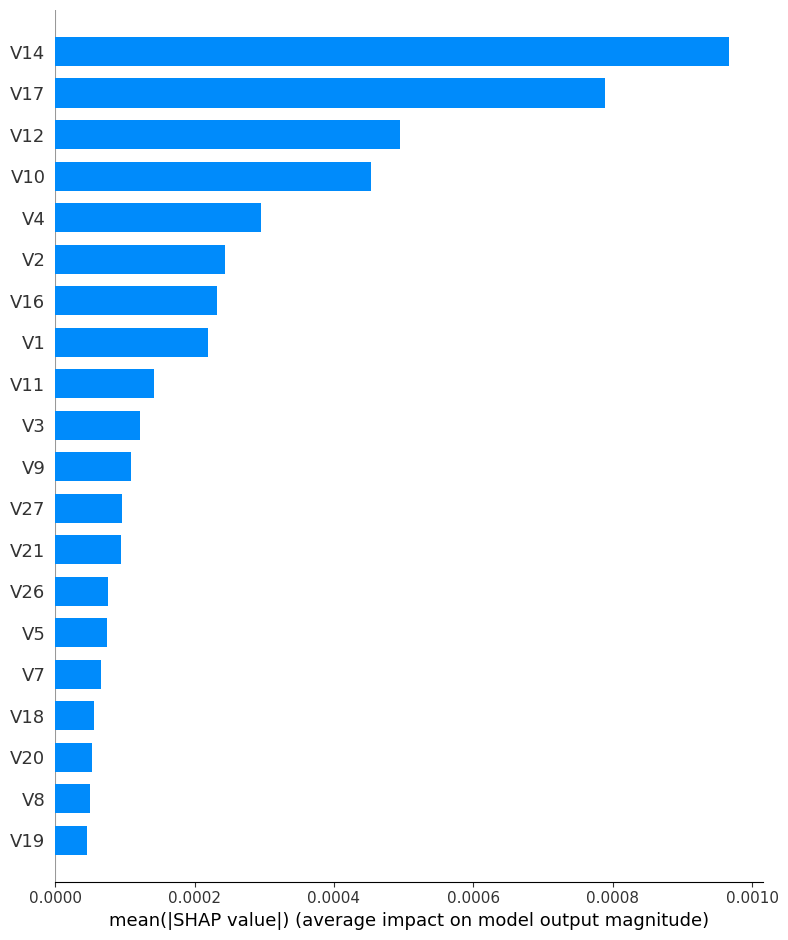

In [51]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

In [52]:
importance.to_csv(
    "../dashboard/feature_importance.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

: 